In [4]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Iterable, Sequence, Mapping

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FixedLocator

from matplotlib.ticker import FixedLocator

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    
from DataUtil import (
    build_experiments,
    DEFAULT_EXPERIMENTS
)

from ObsUtil import (
    OBS_REGISTRY,
    get_obs_file,
    list_obs_sources,
    obs_coverage,
)

from time_window import(
    build_windows_from_start
)


In [43]:
@dataclass(frozen=True)
class FileCollectionConfig:
    group: str
    freq: str
    run: str
    obs: str
    period: str
    model_template: str            # <-- REQUIRED, explicit
    ens_prefix: str = "en"
    ens_width: int = 2
    ens_start: int = 1

    def parse_period(self) -> Tuple[int, int, int, int]:
        m = re.match(r"^(\d{4})(\d{2})-(\d{4})(\d{2})$", self.period)
        if not m:
            raise ValueError(f"Bad period '{self.period}', expected 'YYYYMM-YYYYMM'")
        y0, m0, y1, m1 = map(int, m.groups())
        if (y1, m1) < (y0, m0):
            raise ValueError(f"Bad period '{self.period}' (end < start)")
        return y0, m0, y1, m1

    def years(self) -> List[int]:
        y0, _, y1, _ = self.parse_period()
        return list(range(y0, y1 + 1))

    def ens_labels(self, nens: int) -> List[str]:
        # FIX: use self.ens_start
        return [
            f"{self.ens_prefix}{i:0{self.ens_width}d}"
            for i in range(self.ens_start, nens + self.ens_start)
        ]


class S2SFileCollector:
    """
    Collect obs + model files for S2S / ACC diagnostics.
    """

    def __init__(
        self,
        *,
        exp_list: dict,
        exp_dict: dict,
        obs_registry,
        s2s_var_dict: Dict[str, str],
        get_obs_file_func,
    ):
        self.exp_list = exp_list
        self.exp_dict = exp_dict
        self.obs_registry = obs_registry
        self.s2s_var_dict = s2s_var_dict
        self.get_obs_file = get_obs_file_func

    # ---------- path resolvers ----------

    def resolve_obs_file(
        self,
        obs: str,
        freq: str,
        year: int,
        var: Optional[str] = None,
    ) -> str:
        return self.get_obs_file(
            self.obs_registry,
            obs,
            freq=freq,
            year=year,
            var=var,
        )

    def model_ts_dir(self, run_meta, freq: str) -> str:
        return os.path.join(run_meta.atm_path, "ts", freq)

    def resolve_model_file(
        self,
        *,
        run_meta,
        freq: str,
        year: int,
        var: str,
        ens: str,
        template: str,
    ) -> str:
        ts_dir = self.model_ts_dir(run_meta, freq)
        fname = template % {
            "var": var,
            "ens": ens,
            "year": year,
            "period": run_meta.period,
        }
        return os.path.join(ts_dir, fname)

    # ---------- model file discovery ----------

    def candidates_model_files(
        self,
        *,
        ts_dir: str,
        var: str,
        ens: str,
        years: List[int],
        period: str,
        templates: List[str],
    ) -> List[str]:
        out: List[str] = []
        for tpl in templates:
            for y in years:
                name = tpl % {
                    "var": var,
                    "ens": ens,
                    "year": y,
                    "period": period,
                }
                path = os.path.join(ts_dir, name)
                if os.path.exists(path):
                    out.append(path)

        # de-duplicate while preserving order
        seen = set()
        uniq: List[str] = []
        for p in out:
            if p not in seen:
                uniq.append(p)
                seen.add(p)
        return uniq

    def model_files_for_ens(
        self,
        cfg: FileCollectionConfig,
        *,
        run_meta,
        var: str,
        ens: str,
    ) -> List[str]:
        ts_dir = self.model_ts_dir(run_meta, cfg.freq)
        years = cfg.years()
        return [
            os.path.join(
                ts_dir,
                cfg.model_template % {"var": var, "ens": ens, "year": y, "period": cfg.period},
            )
            for y in years
        ]

    # ---------- main collection ----------

    def collect_one_var(
        self,
        cfg: FileCollectionConfig,
        *,
        var: str,
        obs_var: str,
        verbose: bool = True,
    ):
        years = cfg.years()
        models = self.exp_list[cfg.group]["models"]

        # --- obs files ---
        obs_files = [self.resolve_obs_file(cfg.obs, cfg.freq, y, obs_var) for y in years]
        missing_obs = [f for f in obs_files if not os.path.exists(f)]
        if missing_obs:
            if verbose:
                print(f"[MISSING OBS] {var} (obs_var={obs_var})")
                for f in missing_obs:
                    print("  ", f)
            return None

        out_var = {}

        for exp in models:
            run_meta = self.exp_dict[exp]["runs"][cfg.run]
            if run_meta is None:
                if verbose:
                    print(f"SKIP {exp}: no run='{cfg.run}'")
                continue

            nens = int(self.exp_dict[exp]["nens"])
            ts_dir = self.model_ts_dir(run_meta, cfg.freq)

            model_by_ens = {}
            missing_any = False

            for ens in cfg.ens_labels(nens):
                files = self.model_files_for_ens(cfg, run_meta=run_meta, var=var, ens=ens)

                missing = [f for f in files if not os.path.exists(f)]
                if missing:
                    missing_any = True
                    if verbose:
                        print(f"[MISSING MOD] {exp} {var} {ens} (ts_dir={ts_dir})")
                        for f in missing[:5]:
                            print("   ", f)
                        if len(missing) > 5:
                            print(f"   ... {len(missing)-5} more")

                model_by_ens[ens] = files  # keep full list for later loading

            out_var[exp] = {
                "obs": obs_files,
                "model": model_by_ens,
                "ts_dir": ts_dir,
                "nens": nens,
            }

            if verbose and missing_any:
                print(f"[WARN] {exp} {var}: some ensemble members missing files")

        return out_var

    def collect(
        self,
        cfg: FileCollectionConfig,
        *,
        vars_to_process: Optional[List[str]] = None,
        verbose: bool = True,
    ) -> Dict[str, dict]:
        out: Dict[str, dict] = {}
        for var, obs_var in self.s2s_var_dict.items():
            if vars_to_process is not None and var not in vars_to_process:
                continue

            res = self.collect_one_var(cfg, var=var, obs_var=obs_var, verbose=verbose)
            if res is None:
                continue
            out[var] = res

        return out


# ============================================================
# Physics normalization registries (unchanged)
# ============================================================

FLUX_SIGN_REGISTRY = {
    ("ERA5",  "FLNS"):  +1,
    ("ERA5",  "FLNSC"): +1,
    ("ERA5",  "FSNS"):  +1,
    ("ERA5",  "FSNSC"): +1,
    ("ERA5",  "FLDS"):  +1,
    ("ERA5",  "FSDS"):  +1,
    ("ERA5",  "FLUT"):  +1,

    ("MODEL", "FLNS"):  +1,
    ("MODEL", "FLNSC"): +1,
    ("MODEL", "FSNS"):  +1,
    ("MODEL", "FSNSC"): +1,
    ("MODEL", "FLDS"):  +1,
    ("MODEL", "FSDS"):  +1,
    ("MODEL", "FLUT"):  +1,
}


# ============================================================
# Window configs
# ============================================================

@dataclass(frozen=True)
class WindowedTCCBaseConfig:
    windows: Dict[str, Tuple[str, str]]  # label -> (start_date, end_date), ISO yyyy-mm-dd
    regions: Optional[List[dict]] = None  # [{"name":..., "lat":(lo,hi), "lon":(lo,hi)}]
    lat_range: Optional[Tuple[float, float]] = None
    lon_range: Optional[Tuple[float, float]] = None

    # grid/time checks
    require_same_grid: bool = True
    grid_tol: float = 0.0
    require_nonempty_time: bool = True

    # output
    out_dir: str = "./base_tcc_rmse"
    overwrite: bool = False
    verbose: bool = True


@dataclass(frozen=True)
class WindowedTCCAggregateConfig:
    member_quantiles: Tuple[float, ...] = (0.1, 0.5, 0.9)
    overwrite: bool = True
    verbose: bool = True


# ============================================================
# Stage 1: base builder (UPDATED to compute/save BIAS)
# ============================================================

class S2SWindowedTCCBaseBuilder:
    """
    Stage 1: build base files per (exp, var, ens).
      output file contains:
        - TCC(window, lat, lon)
        - RMSE(window, lat, lon)
        - BIAS(window, lat, lon)   <-- NEW
        - coords: window_start/window_end
        - attrs: exp/ens/var/region/period
    """

    def __init__(self, cfg: WindowedTCCBaseConfig):
        self.cfg = cfg
        os.makedirs(self.cfg.out_dir, exist_ok=True)

    # ---------- helpers ----------

    @staticmethod
    def _parse_yyyymm_period(period: str) -> Tuple[int, int, int, int]:
        m = re.match(r"^(\d{4})(\d{2})-(\d{4})(\d{2})$", period)
        if not m:
            raise ValueError(f"Bad period '{period}', expected 'YYYYMM-YYYYMM'")
        y0, m0, y1, m1 = map(int, m.groups())
        return y0, m0, y1, m1

    @classmethod
    def _select_period_time(cls, da: xr.DataArray, period: str) -> xr.DataArray:
        y0, m0, y1, m1 = cls._parse_yyyymm_period(period)
        t0 = np.datetime64(f"{y0:04d}-{m0:02d}-01")
        if m1 == 12:
            t1 = np.datetime64(f"{y1 + 1:04d}-01-01")
        else:
            t1 = np.datetime64(f"{y1:04d}-{m1 + 1:02d}-01")
        return da.sel(time=slice(t0, t1))

    @staticmethod
    def _to_daily_date_time(da: xr.DataArray) -> xr.DataArray:
        if "time" not in da.coords:
            raise KeyError("Missing time coordinate.")
        t = da["time"]

        if np.issubdtype(t.dtype, np.datetime64):
            t_daily = t.astype("datetime64[D]")
        else:
            t_daily = xr.DataArray(
                np.array([np.datetime64(str(v)[:10]) for v in t.values], dtype="datetime64[D]"),
                dims=t.dims, coords=t.coords, name=t.name
            )

        out = da.assign_coords(time=t_daily)

        # collapse duplicates after daily casting
        if out.indexes["time"].has_duplicates:
            out = out.groupby("time").mean("time")

        return out

    @staticmethod
    def _open_var(files: List[str], var: str) -> xr.DataArray:
        ds = xr.open_mfdataset(files, combine="by_coords")
        if var in ds:
            return ds[var]
        for k in ds.data_vars:
            if k.lower() == var.lower():
                return ds[k]
        raise KeyError(f"Variable '{var}' not found in files. Available={list(ds.data_vars)}")

    @staticmethod
    def _guess_lat_lon_names(da: xr.DataArray) -> Tuple[str, str]:
        lat_candidates = ["lat", "latitude", "LAT", "nlat"]
        lon_candidates = ["lon", "longitude", "LON", "nlon"]
        lat = next((n for n in lat_candidates if (n in da.dims or n in da.coords)), None)
        lon = next((n for n in lon_candidates if (n in da.dims or n in da.coords)), None)
        if lat is None or lon is None:
            raise ValueError(f"Cannot infer lat/lon. dims={da.dims} coords={list(da.coords)}")
        return lat, lon

    @staticmethod
    def _wrap_lon_0_360(da: xr.DataArray, lon_name: str) -> xr.DataArray:
        if lon_name not in da.coords:
            return da
        lon = da[lon_name]
        if not np.issubdtype(lon.dtype, np.number):
            return da
        lon2 = (lon % 360.0)
        return da.assign_coords({lon_name: lon2}).sortby(lon_name)

    @staticmethod
    def _subset_region(
        da: xr.DataArray,
        lat: str,
        lon: str,
        lat_range: Optional[Tuple[float, float]],
        lon_range: Optional[Tuple[float, float]],
    ) -> xr.DataArray:
        out = da
        if lat_range is not None:
            lo, hi = lat_range
            latv = out[lat]
            if latv.size > 1 and (latv[0] > latv[-1]):
                out = out.sel({lat: slice(hi, lo)})
            else:
                out = out.sel({lat: slice(lo, hi)})
        if lon_range is not None:
            lo, hi = lon_range
            out = out.sel({lon: slice(lo, hi)})
        return out

    @staticmethod
    def _same_1d_values(a: xr.DataArray, b: xr.DataArray, tol: float) -> bool:
        if a.size != b.size:
            return False
        av = np.asarray(a.values)
        bv = np.asarray(b.values)
        if tol == 0.0:
            return np.array_equal(av, bv)
        return np.allclose(av, bv, rtol=0.0, atol=tol, equal_nan=True)

    @staticmethod
    def _rename_dim_if_present(da: xr.DataArray, old: str, new: str) -> xr.DataArray:
        if old == new:
            return da
        if (new in da.dims) or (new in da.coords):
            return da
        rename_map = {}
        if old in da.dims:
            rename_map[old] = new
        if old in da.coords:
            rename_map[old] = new
        return da.rename(rename_map) if rename_map else da

    def _ensure_names_match(
        self,
        mod: xr.DataArray,
        obs: xr.DataArray,
        mod_lat: str,
        mod_lon: str,
        obs_lat: str,
        obs_lon: str,
    ) -> xr.DataArray:
        if (mod_lat == obs_lat) and (mod_lon == obs_lon):
            return mod
        lat_ok = self._same_1d_values(mod[mod_lat], obs[obs_lat], self.cfg.grid_tol)
        lon_ok = self._same_1d_values(mod[mod_lon], obs[obs_lon], self.cfg.grid_tol)
        if self.cfg.require_same_grid and not (lat_ok and lon_ok):
            raise ValueError("Model/obs grids differ; regrid explicitly or set require_same_grid=False.")
        mod = self._rename_dim_if_present(mod, mod_lat, obs_lat)
        mod = self._rename_dim_if_present(mod, mod_lon, obs_lon)
        return mod

    def _align_and_check(self, mod: xr.DataArray, obs: xr.DataArray) -> tuple[xr.DataArray, xr.DataArray]:
        mod, obs = xr.align(mod, obs, join="inner")
        mod = mod.sortby("time")
        obs = obs.sortby("time")
        if self.cfg.require_nonempty_time and mod.sizes.get("time", 0) == 0:
            raise ValueError("No overlapping times between model and obs after alignment.")
        return mod, obs

    # ---------- kernels ----------
    @staticmethod
    def _maybe_convert_precip_to_mmday(da: xr.DataArray, *, var_key: str, verbose: bool = False) -> xr.DataArray:
        k = (var_key or "").lower()
        name = (da.name or "").lower()

        is_pr = (
            k in ("pr", "precip", "prect", "precc", "precl", "precsl", "tp")
            or "precip" in k or "precip" in name
            or k.startswith("pr") or name.startswith("pr")
            or name in ("prect", "precc", "precl", "precsl", "tp")
        )
        if not is_pr:
            return da

        u = (da.attrs.get("units") or "").strip().lower()
        u0 = u.replace(" ", "")

        def _set(out, note):
            out.attrs = dict(da.attrs)
            out.attrs["units"] = "mm/day"
            out.attrs["note_unit_fix"] = note
            return out

        if u0 in ("mm/day", "mm/d", "mmd-1", "mmdy-1") or ("mm" in u0 and ("day" in u0 or "d-1" in u0)):
            return da

        if ("kg" in u0 and "m-2" in u0 and "s-1" in u0) or u0 in ("kgm-2s-1", "kg/m2/s", "kgm**-2s**-1"):
            if verbose:
                print(f"[UNIT FIX] {da.name or var_key}: kg m-2 s-1 -> mm/day (×86400)")
            return _set(da * 86400.0, "converted from kg m-2 s-1 via ×86400")

        if u0 in ("m/s", "ms-1") or ("m" in u0 and "s-1" in u0 and "kg" not in u0 and "mm" not in u0):
            if verbose:
                print(f"[UNIT FIX] {da.name or var_key}: m/s -> mm/day (×86400×1000)")
            return _set(da * 86400.0 * 1000.0, "converted from m s-1 via ×86400×1000")

        if u0 in ("mm/s", "mms-1"):
            if verbose:
                print(f"[UNIT FIX] {da.name or var_key}: mm/s -> mm/day (×86400)")
            return _set(da * 86400.0, "converted from mm s-1 via ×86400")

        if u0 in ("m/day", "m/d", "md-1"):
            if verbose:
                print(f"[UNIT FIX] {da.name or var_key}: m/day -> mm/day (×1000)")
            return _set(da * 1000.0, "converted from m day-1 via ×1000")

        return da

    @staticmethod
    def _maybe_convert_geopotential_to_height(
        da: xr.DataArray,
        *,
        var_key: str,
        g: float = 9.80665,
        verbose: bool = False,
    ) -> xr.DataArray:
        k = (var_key or "").lower()
        name = (da.name or "").lower()

        looks_like_z = (
            k.startswith("z")
            or "geopot" in k
            or "geopot" in name
            or name.startswith("z")
            or name in ("zg", "phi")
        )
        if not looks_like_z:
            return da

        units = (da.attrs.get("units") or "").strip().lower()
        u0 = units.replace(" ", "").replace("^", "").replace("**", "")

        def is_geopot(u: str) -> bool:
            return ("m2s-2" in u) or ("m2/s2" in u)

        def is_height(u: str) -> bool:
            return u in ("m", "meter", "metre", "meters", "metres")

        if u0:
            if is_geopot(u0):
                if verbose:
                    print(f"[UNIT FIX] {da.name or var_key}: geopotential -> height (÷g)")
                out = da / g
                out.attrs = dict(da.attrs)
                out.attrs["units"] = "m"
                out.attrs["note_unit_fix"] = "converted from geopotential (m2 s-2) via /g"
                return out
            if is_height(u0):
                return da

        try:
            vmax = float(da.max(skipna=True))
        except Exception:
            return da

        if 2.0e4 < vmax < 5.0e6:
            if verbose:
                print(f"[UNIT FIX] {da.name or var_key}: heuristic geopotential -> height (÷g), vmax={vmax:.3g}")
            out = da / g
            out.attrs = dict(da.attrs)
            out.attrs["units"] = "m"
            out.attrs["note_unit_fix"] = "heuristic geopotential->height via /g (units missing/unknown)"
            return out

        return da

    def _maybe_fix_flux_sign_by_registry(
        self,
        da: xr.DataArray,
        *,
        var_key: str,
        source: str,   # "ERA5" / "MODEL" / "NOAA-OLR" ...
        registry: dict,
    ) -> xr.DataArray:
        v = (var_key or da.name or "").upper()

        s = registry.get((source, v), registry.get(v, +1))
        s = int(s)

        if s == -1:
            out = -da
            out.attrs = dict(da.attrs)
            out.attrs["note_sign_fix"] = f"flipped sign by registry: ({source},{v})"
            return out
        return da

    def _normalize_physics(self, da: xr.DataArray, *, var_key: str, source: str) -> xr.DataArray:
        """
        Normalize per-field physics once (no window loop cost):
          - lon to [0,360)
          - daily time coordinate
          - precip to mm/day (if needed)
          - geopotential -> height (if needed)
          - flux sign by registry (if needed)
        """
        lat, lon = self._guess_lat_lon_names(da)
        da = self._wrap_lon_0_360(da, lon)

        da = self._to_daily_date_time(da)

        da = self._maybe_convert_precip_to_mmday(da, var_key=var_key, verbose=self.cfg.verbose)
        da = self._maybe_convert_geopotential_to_height(da, var_key=var_key, verbose=self.cfg.verbose)

        da = self._maybe_fix_flux_sign_by_registry(
            da, var_key=var_key, source=source, registry=FLUX_SIGN_REGISTRY
        )
        return da

    @staticmethod
    def _tcc_over_time(
        f: xr.DataArray,
        o: xr.DataArray,
        *,
        min_count: int = 2,
    ) -> xr.DataArray:
        valid = f.notnull() & o.notnull()
        f2 = f.where(valid)
        o2 = o.where(valid)

        fa = f2 - f2.mean("time", skipna=True)
        oa = o2 - o2.mean("time", skipna=True)

        num = (fa * oa).sum("time", skipna=True)
        den = xr.ufuncs.sqrt(
            (fa * fa).sum("time", skipna=True)
            * (oa * oa).sum("time", skipna=True)
        )

        n = valid.sum("time")
        out = (num / den).where((den > 0) & (n >= min_count))
        return out

    @staticmethod
    def _rmse_over_time(f: xr.DataArray, o: xr.DataArray, *, min_count: int = 1) -> xr.DataArray:
        d2 = (f - o) ** 2
        mse = d2.mean("time", skipna=True)
        if min_count > 1:
            n = d2.notnull().sum("time")
            mse = mse.where(n >= min_count)
        return xr.ufuncs.sqrt(mse)

    # NEW: Bias = mean(f - o)
    @staticmethod
    def _bias_over_time(f: xr.DataArray, o: xr.DataArray, *, min_count: int = 1) -> xr.DataArray:
        valid = f.notnull() & o.notnull()
        d = (f - o).where(valid)

        bias = d.mean("time", skipna=True)

        if min_count > 1:
            n = valid.sum("time")
            bias = bias.where(n >= min_count)

        return bias

    # ---------- filenames ----------

    def base_path(
        self,
        *,
        group: str,
        freq: str,
        run: str,
        obs: str,
        period: str,
        region: str,
        exp: str,
        var: str,
        ens: str,
    ) -> str:
        fname = f"s2s_base_tcc_rmse_{group}_{freq}_{run}_{obs}_{period}_{region}_{exp}_{ens}_{var}.nc"
        return os.path.join(self.cfg.out_dir, fname)

    def ensmean_path(
        self,
        *,
        group: str,
        freq: str,
        run: str,
        obs: str,
        period: str,
        region: str,
        exp: str,
        var: str,
    ) -> str:
        fname = f"s2s_base_tcc_rmse_{group}_{freq}_{run}_{obs}_{period}_{region}_{exp}_ENSMEAN_{var}.nc"
        return os.path.join(self.cfg.out_dir, fname)

    @staticmethod
    def _print_da_extent(tag: str, da: xr.DataArray):
        def _rng(x):
            try:
                return float(x.min()), float(x.max()), x.size
            except Exception:
                return None

        msg = [f"[{tag}]"]

        if "time" in da.coords:
            t = da["time"]
            msg.append(f"time={str(t.min().values)[:10]} → {str(t.max().values)[:10]} (n={t.size})")

        for dim in ("lat", "latitude"):
            if dim in da.coords:
                lo, hi, n = _rng(da[dim])
                msg.append(f"{dim}={lo:.2f} → {hi:.2f} (n={n})")
                break

        for dim in ("lon", "longitude"):
            if dim in da.coords:
                lo, hi, n = _rng(da[dim])
                msg.append(f"{dim}={lo:.2f} → {hi:.2f} (n={n})")
                break

        print(" | ".join(msg))

    # ---------- main: build per member ----------
    def build_member_file(
        self,
        all_files: Dict[str, dict],
        *,
        group: str,
        freq: str,
        run: str,
        obs_name: str,
        period: str,
        var: str,
        exp: str,
        ens: str,
        obs_var_override: Optional[Dict[str, str]] = None,
    ) -> str:
        """
        Build ONE base file for a single (exp, var, ens) across all configured regions.
        Saves: TCC, RMSE, BIAS.
        """
        if var not in all_files or exp not in all_files[var]:
            raise KeyError(f"Missing var/exp in all_files: var={var} exp={exp}")

        regions = self.cfg.regions or [dict(name="DEFAULT", lat=self.cfg.lat_range, lon=self.cfg.lon_range)]

        # open obs once
        obs_files = all_files[var][exp]["obs"]
        obs_var = (obs_var_override or {}).get(var, var)
        obs0 = self._open_var(obs_files, obs_var)
        obs0 = self._select_period_time(obs0, period)
        obs0 = self._normalize_physics(obs0, var_key=var, source=obs_name)
        if self.cfg.verbose:
            self._print_da_extent(f"OBS normalized ({var})", obs0)

        lat_obs, lon_obs = self._guess_lat_lon_names(obs0)

        # open member once
        model_files = all_files[var][exp]["model"].get(ens, [])
        if not model_files:
            raise FileNotFoundError(f"No model files for exp={exp} var={var} ens={ens}")

        mem = self._open_var(model_files, var)
        mem = self._select_period_time(mem, period)
        mem = self._normalize_physics(mem, var_key=var, source="MODEL")
        if self.cfg.verbose:
            self._print_da_extent(f"MODEL normalized ({exp} {ens} {var})", mem)

        lat_m, lon_m = self._guess_lat_lon_names(mem)

        # per-region compute and pack
        reg_ds_list = []
        for reg in regions:
            rname = str(reg.get("name", "REGION"))
            rlat = reg.get("lat", None)
            rlon = reg.get("lon", None)

            obs_reg = self._subset_region(obs0, lat_obs, lon_obs, rlat, rlon)
            mem_reg = self._subset_region(mem, lat_m, lon_m, rlat, rlon)
            mem_reg = self._ensure_names_match(mem_reg, obs_reg, lat_m, lon_m, lat_obs, lon_obs)
            mem_a, obs_a = self._align_and_check(mem_reg, obs_reg)

            if self.cfg.verbose:
                self._print_da_extent(f"ALIGNED OBS region={rname}", obs_a)
                self._print_da_extent(f"ALIGNED MODEL region={rname}", mem_a)

            wlabels, wstart, wend = [], [], []
            tcc_list, rmse_list, bias_list = [], [], []  # NEW bias_list

            for wlab in sorted(self.cfg.windows.keys()):
                s, e = self.cfg.windows[wlab]
                ts = slice(np.datetime64(s), np.datetime64(e))
                f = mem_a.sel(time=ts)
                o = obs_a.sel(time=ts)
                if self.cfg.verbose:
                    self._print_da_extent(f"WINDOW {wlab} OBS", o)
                    self._print_da_extent(f"WINDOW {wlab} MODEL", f)
                if f.sizes.get("time", 0) == 0:
                    continue

                tcc_list.append(self._tcc_over_time(f, o))
                rmse_list.append(self._rmse_over_time(f, o))
                bias_list.append(self._bias_over_time(f, o))  # NEW

                wlabels.append(wlab)
                wstart.append(np.datetime64(s))
                wend.append(np.datetime64(e))

            if not tcc_list:
                if self.cfg.verbose:
                    print(f"[SKIP] no windows produced for {exp} {ens} {var} region={rname}")
                continue

            TCC = xr.concat(tcc_list, dim=xr.IndexVariable("window", wlabels))
            RMSE = xr.concat(rmse_list, dim=xr.IndexVariable("window", wlabels))
            BIAS = xr.concat(bias_list, dim=xr.IndexVariable("window", wlabels))  # NEW

            TCC = TCC.assign_coords(
                window_start=("window", np.array(wstart, dtype="datetime64[D]")),
                window_end=("window", np.array(wend, dtype="datetime64[D]")),
            )
            RMSE = RMSE.assign_coords(window_start=TCC["window_start"], window_end=TCC["window_end"])
            BIAS = BIAS.assign_coords(window_start=TCC["window_start"], window_end=TCC["window_end"])  # NEW

            ds_reg = xr.Dataset(
                data_vars=dict(
                    TCC=TCC,
                    RMSE=RMSE,
                    BIAS=BIAS,  # NEW
                ),
                coords=dict(window=TCC["window"]),
                attrs=dict(region=rname),
            ).assign_coords(region=rname).expand_dims("region")

            reg_ds_list.append(ds_reg)

        if not reg_ds_list:
            raise ValueError(f"No region results produced for exp={exp} ens={ens} var={var}")

        ds_out = xr.concat(reg_ds_list, dim="region")
        ds_out.attrs.update(
            dict(
                group=group,
                freq=freq,
                run=run,
                obs=obs_name,
                period=period,
                exp=exp,
                ens=ens,
                var=var,
                note="Base file: windowed TCC/RMSE/BIAS maps for a single ensemble member.",
            )
        )

        path = self.base_path(
            group=group, freq=freq, run=run, obs=obs_name, period=period,
            region="ALL", exp=exp, var=var, ens=ens
        )
        if (not self.cfg.overwrite) and os.path.exists(path):
            if self.cfg.verbose:
                print(f"[SKIP EXISTS] {path}")
            return path

        ds_out.to_netcdf(path)
        if self.cfg.verbose:
            print(f"[SAVED] {path}")
        return path

    def build_ensmean_file(
        self,
        all_files: Dict[str, dict],
        *,
        group: str,
        freq: str,
        run: str,
        obs_name: str,
        period: str,
        var: str,
        exp: str,
        obs_var_override: Optional[Dict[str, str]] = None,
    ) -> str:
        """
        Build ONE base file for ensemble-mean-based windowed TCC/RMSE/BIAS maps: (exp, var).
        """
        if var not in all_files or exp not in all_files[var]:
            raise KeyError(f"Missing var/exp in all_files: var={var} exp={exp}")

        regions = self.cfg.regions or [dict(name="DEFAULT", lat=self.cfg.lat_range, lon=self.cfg.lon_range)]

        # ---- open obs once ----
        obs_files = all_files[var][exp]["obs"]
        obs_var = (obs_var_override or {}).get(var, var)

        obs0 = self._open_var(obs_files, obs_var)
        obs0 = self._select_period_time(obs0, period)
        obs0 = self._normalize_physics(obs0, var_key=var, source=obs_name)
        if self.cfg.verbose:
            self._print_da_extent(f"OBS normalized ({var})", obs0)

        lat_obs, lon_obs = self._guess_lat_lon_names(obs0)

        # ---- open + build ensemble mean once ----
        model_by_ens = all_files[var][exp]["model"]
        members = []
        ens_names = []
        for ens, files in model_by_ens.items():
            if not files:
                continue
            da = self._open_var(files, var)
            da = self._select_period_time(da, period)
            da = self._normalize_physics(da, var_key=var, source="MODEL")
            members.append(da)
            ens_names.append(ens)

        if not members:
            raise ValueError(f"No member data for exp={exp} var={var}")

        mod_ens = xr.concat(members, dim=xr.IndexVariable("ens", ens_names))
        mod_mean = mod_ens.mean("ens")
        lat_m, lon_m = self._guess_lat_lon_names(mod_mean)

        # ---- per-region compute ----
        reg_ds_list = []
        for reg in regions:
            rname = str(reg.get("name", "REGION"))
            rlat = reg.get("lat", None)
            rlon = reg.get("lon", None)

            obs_reg = self._subset_region(obs0, lat_obs, lon_obs, rlat, rlon)
            mod_reg = self._subset_region(mod_mean, lat_m, lon_m, rlat, rlon)

            mod_reg = self._ensure_names_match(mod_reg, obs_reg, lat_m, lon_m, lat_obs, lon_obs)
            mod_a, obs_a = self._align_and_check(mod_reg, obs_reg)

            wlabels, wstart, wend = [], [], []
            tcc_list, rmse_list, bias_list = [], [], []  # NEW bias_list

            for wlab in sorted(self.cfg.windows.keys()):
                s, e = self.cfg.windows[wlab]
                ts = slice(np.datetime64(s), np.datetime64(e))
                f = mod_a.sel(time=ts)
                o = obs_a.sel(time=ts)
                if f.sizes.get("time", 0) == 0:
                    continue

                tcc_list.append(self._tcc_over_time(f, o))
                rmse_list.append(self._rmse_over_time(f, o))
                bias_list.append(self._bias_over_time(f, o))  # NEW

                wlabels.append(wlab)
                wstart.append(np.datetime64(s))
                wend.append(np.datetime64(e))

            if not tcc_list:
                if self.cfg.verbose:
                    print(f"[SKIP] ensmean: no windows produced for {exp} {var} region={rname}")
                continue

            TCC = xr.concat(tcc_list, dim=xr.IndexVariable("window", wlabels))
            RMSE = xr.concat(rmse_list, dim=xr.IndexVariable("window", wlabels))
            BIAS = xr.concat(bias_list, dim=xr.IndexVariable("window", wlabels))  # NEW

            TCC = TCC.assign_coords(
                window_start=("window", np.array(wstart, dtype="datetime64[D]")),
                window_end=("window", np.array(wend, dtype="datetime64[D]")),
            )
            RMSE = RMSE.assign_coords(window_start=TCC["window_start"], window_end=TCC["window_end"])
            BIAS = BIAS.assign_coords(window_start=TCC["window_start"], window_end=TCC["window_end"])  # NEW

            ds_reg = xr.Dataset(
                data_vars=dict(
                    TCC_ensmean=TCC,
                    RMSE_ensmean=RMSE,
                    BIAS_ensmean=BIAS,  # NEW
                ),
                coords=dict(window=TCC["window"]),
                attrs=dict(region=rname),
            ).assign_coords(region=rname).expand_dims("region")

            reg_ds_list.append(ds_reg)

        if not reg_ds_list:
            raise ValueError(f"No ensmean region results produced for exp={exp} var={var}")

        ds_out = xr.concat(reg_ds_list, dim="region")
        ds_out.attrs.update(
            dict(
                group=group, freq=freq, run=run, obs=obs_name, period=period,
                exp=exp, var=var,
                note="Ensemble-mean-based base file: windowed TCC/RMSE/BIAS maps computed from ensemble-mean time series.",
            )
        )

        path = self.ensmean_path(
            group=group, freq=freq, run=run, obs=obs_name, period=period,
            region="ALL", exp=exp, var=var
        )
        if (not self.cfg.overwrite) and os.path.exists(path):
            if self.cfg.verbose:
                print(f"[SKIP EXISTS] {path}")
            return path

        ds_out.to_netcdf(path)
        if self.cfg.verbose:
            print(f"[SAVED] {path}")
        return path


# ============================================================
# Stage 2: aggregator (UPDATED to aggregate BIAS)
# ============================================================

class S2SWindowedTCCAggregator:
    """
    Stage 2: aggregate member base files into ensemble summary for each (exp,var).
    Produces:
      - TCC_mean/std/quantile over ens
      - RMSE_mean/std/quantile over ens
      - BIAS_mean/std/quantile over ens   <-- NEW
      - optional: *_ensmean from ensmean base file
    """

    def __init__(self, cfg: WindowedTCCAggregateConfig):
        self.cfg = cfg

    @staticmethod
    def _open_many(paths: List[str]) -> xr.Dataset:
        return xr.open_mfdataset(paths, combine="by_coords")

    def aggregate_exp_var(
        self,
        member_paths: List[str],
        *,
        out_nc: str,
        ensmean_path: str | None = None,
    ) -> str:

        ds_list = []
        ens_names = []
        for p in member_paths:
            ds = xr.open_dataset(p)
            ens = str(ds.attrs.get("ens", "ens"))
            ds_list.append(ds.load())
            ds.close()
            ens_names.append(ens)

        ds_ens = xr.concat(ds_list, dim=xr.IndexVariable("ens", ens_names))

        out = xr.Dataset()
        out["TCC_member"] = ds_ens["TCC"]
        out["RMSE_member"] = ds_ens["RMSE"]
        out["BIAS_member"] = ds_ens["BIAS"]  # NEW

        out["TCC_mean"] = out["TCC_member"].mean("ens")
        out["RMSE_mean"] = out["RMSE_member"].mean("ens")
        out["BIAS_mean"] = out["BIAS_member"].mean("ens")  # NEW

        out["TCC_std"] = out["TCC_member"].std("ens")
        out["RMSE_std"] = out["RMSE_member"].std("ens")
        out["BIAS_std"] = out["BIAS_member"].std("ens")  # NEW

        qs = list(self.cfg.member_quantiles or ())
        if qs:
            out["TCC_quantile"] = out["TCC_member"].quantile(qs, dim="ens").rename({"quantile": "q"})
            out["RMSE_quantile"] = out["RMSE_member"].quantile(qs, dim="ens").rename({"quantile": "q"})
            out["BIAS_quantile"] = out["BIAS_member"].quantile(qs, dim="ens").rename({"quantile": "q"})  # NEW

        # add ensmean diagnostics if provided
        if ensmean_path is not None and os.path.exists(ensmean_path):
            ds_em = xr.open_dataset(ensmean_path)
            if "TCC_ensmean" in ds_em:
                out["TCC_ensmean"] = ds_em["TCC_ensmean"]
            if "RMSE_ensmean" in ds_em:
                out["RMSE_ensmean"] = ds_em["RMSE_ensmean"]
            if "BIAS_ensmean" in ds_em:  # NEW
                out["BIAS_ensmean"] = ds_em["BIAS_ensmean"]
            ds_em.close()

        # attrs
        for k, v in ds_list[0].attrs.items():
            out.attrs[k] = v
        out.attrs["note"] = (
            "Ensemble aggregation from per-member base files "
            "(mean/std/quantiles) + optional ensmean-based diagnostics. "
            "Includes TCC/RMSE/BIAS."
        )

        if (not self.cfg.overwrite) and os.path.exists(out_nc):
            raise FileExistsError(f"Output exists: {out_nc}")

        out.to_netcdf(out_nc)
        if self.cfg.verbose:
            print(f"[SAVED] {out_nc}")
        return out_nc


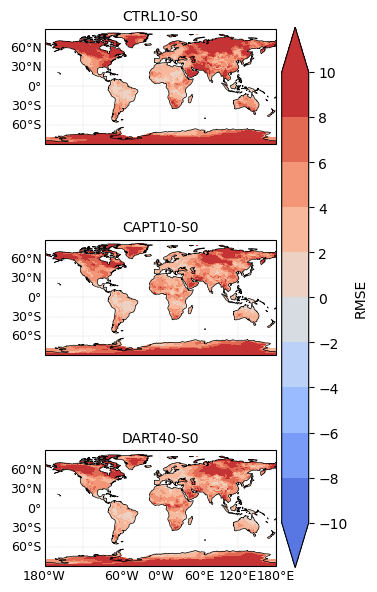

In [44]:
if __name__ == "__main__":
    data_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    diag_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_output/tcc_rmse_base"
    land_mask = "/compyfs/zhan391/acme_init/lnd_sea_mask/landmask_1x1.nc"
    fig_path = "./"
    
    # landmask settings
    landmask_var = "landfrac"
    land_threshold = 0.5

    # config knobs
    ens_start = 1
    ens_prefix = "EN"
    ens_width = 2
    ensmean_tag = "ENSMEAN"
    include_ensmean = True
    compute_ensmean_if_missing = False

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            period="201201-201203",
            season="Winter",
            init_date="2012-01-01",
            init_month=1,
            run="fc",
            freq="daily",
        ),
        "Jun2012": dict(
            models=["CTRL10-S1", "CAPT10-S1", "DART40-S1"],
            period="201206-201208",
            season="Summer",
            init_date="2012-06-01",
            init_month=6,
            run="fc",
            freq="daily",
        ),
    }
    
    # obs -> {model_var -> obs_var}
    all_var_dict = {
        "ERA5": {
            "UBOT": "U10",
            "VBOT": "V10",
            "PRECT": "PRECT",
            "PSL": "PSL",
            "U850": "U850",
            "V850": "V850",
            "T850": "T850",
            "Q850": "Q850",
            "Z500": "Z500",
            "OMEGA500": "OMEGA500",
            "OMEGA200": "OMEGA200",
            "OMEGA850": "OMEGA850",
            "U200": "U200",
            "V200": "V200",
            "U500": "U500",
            "V500": "V500",
            "FLDS": "FLDS",
            "FLDSC": "FLDSC",
            "FLNS": "FLNS",
            "FLNSC": "FLNSC",
            "FSDS": "FSDS",
            "FSDSC": "FSDSC",
            "FSNS": "FSNS",
            "FSNSC": "FSNSC",
            "LHFLX": "LHFLX",
            "SHFLX": "SHFLX",
            "QFLX": "QFLX",
            "TREFHT": "TREFHT",
            "TS": "TS",
            "PRECSL": "PRECSL",
            "PRECC": "PRECC",
            "PRECL": "PRECL",
        },
        "GPCP": {"PRECT": "PRECT"},
        "GPM": {"PRECT": "PRECT"},
        "NOAA-OLR": {"FLUT": "FLUT"},
    }

    lead_bins = {
        "week1-2": (1, 14),
        "week3-4": (15, 28),
        "week5-6": (29, 42),
        "week7-8": (43, 56),
    }

    # choice on plot
    group = "Jan2012"
    obs = "ERA5"
    region = "ALL"
    prefix = "s2s_base_tcc_rmse"
    var_map = all_var_dict[obs]
    # obs_var = var_map.get(diag_var, diag_var)  # if you need it later
    

    # setup for figures
    diag_var = "TREFHT"
    metric = "RMSE"
    window = "week1-2"

    vmin = -10
    vmax = 10
    var_levels = np.linspace(vmin,vmax,11)
    cmap = "coolwarm"
    mask="land" # or "ocean" or "None"
    ncols = 1

    # FIX 1: no trailing comma
    figname = Path(f"{fig_path}/fig_{metric}_map_{diag_var}_{obs}_{window}.png")
    suptitle = "" # f"{group} {diag_var} {metric} {window} ({obs})",
    
    input_dir = Path(f"{diag_path}/{group}")
    if not input_dir.exists():
        raise FileNotFoundError(f"input_dir not found: {input_dir}")

    # experiment info
    freq = exp_list[group]["freq"]
    run = exp_list[group]["run"]
    models = ["CTRL10-S0","CAPT10-S0", "DART40-S0"] #exp_list[group]["models"]
    period = exp_list[group]["period"]

    exp_order = tuple(models)
    baseline_exp = models[0]
    
    # build exp metadata once
    exp_dict = build_experiments(data_path)
    nens_by_exp = {exp: int(exp_dict[exp]["nens"]) for exp in models}
    
    cfg = TccWindowMapPlotConfig(
        input_dir=input_dir,
        prefix=prefix,
        group=group,
        freq=freq,
        run=run,
        obs=obs,
        period=period,
        region=region,
        exp_order=exp_order,
        nens=nens_by_exp,  
        ens_start=ens_start,
        ens_prefix=ens_prefix,
        ens_width=ens_width,
        include_ensmean=include_ensmean,
        ensmean_tag=ensmean_tag,
        compute_ensmean_if_missing=compute_ensmean_if_missing,
        lead_bins=lead_bins,
        vmin=vmin,
        vmax=vmax,
        ncols=ncols,
        cmap = cmap,
        mask = mask, 
        mask_file=land_mask,
        mask_var=landmask_var,
        mask_threshold=land_threshold,
    )
    
    plotter = TccWindowMapPlotter(cfg)

    plotter.plot_window_maps_all_exps(
        var=diag_var,
        exps=models,
        window=window,
        metric=metric,
        out_png=figname,
        suptitle=suptitle,
        var_levels = var_levels, 
        show=True,
    )

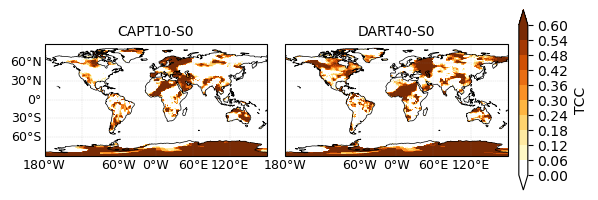

In [35]:
if __name__ == "__main__":
    data_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    diag_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_output/tcc_rmse_base"
    land_mask = "/compyfs/zhan391/acme_init/lnd_sea_mask/landmask_1x1.nc"
    fig_path = "./"
    
    # landmask settings
    landmask_var = "landfrac"
    land_threshold = 0.5

    # config knobs
    ens_start = 1
    ens_prefix = "EN"
    ens_width = 2
    ensmean_tag = "ENSMEAN"
    include_ensmean = True
    compute_ensmean_if_missing = False

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            period="201201-201203",
            season="Winter",
            init_date="2012-01-01",
            init_month=1,
            run="fc",
            freq="daily",
        ),
        "Jun2012": dict(
            models=["CTRL10-S1", "CAPT10-S1", "DART40-S1"],
            period="201206-201208",
            season="Summer",
            init_date="2012-06-01",
            init_month=6,
            run="fc",
            freq="daily",
        ),
    }
    
    # obs -> {model_var -> obs_var}
    all_var_dict = {
        "ERA5": {
            "UBOT": "U10",
            "VBOT": "V10",
            "PRECT": "PRECT",
            "PSL": "PSL",
            "U850": "U850",
            "V850": "V850",
            "T850": "T850",
            "Q850": "Q850",
            "Z500": "Z500",
            "OMEGA500": "OMEGA500",
            "OMEGA200": "OMEGA200",
            "OMEGA850": "OMEGA850",
            "U200": "U200",
            "V200": "V200",
            "U500": "U500",
            "V500": "V500",
            "FLDS": "FLDS",
            "FLDSC": "FLDSC",
            "FLNS": "FLNS",
            "FLNSC": "FLNSC",
            "FSDS": "FSDS",
            "FSDSC": "FSDSC",
            "FSNS": "FSNS",
            "FSNSC": "FSNSC",
            "LHFLX": "LHFLX",
            "SHFLX": "SHFLX",
            "QFLX": "QFLX",
            "TREFHT": "TREFHT",
            "TS": "TS",
            "PRECSL": "PRECSL",
            "PRECC": "PRECC",
            "PRECL": "PRECL",
        },
        "GPCP": {"PRECT": "PRECT"},
        "GPM": {"PRECT": "PRECT"},
        "NOAA-OLR": {"FLUT": "FLUT"},
    }

    lead_bins = {
        "week1-2": (1, 14),
        "week3-4": (15, 28),
        "week5-6": (29, 42),
        "week7-8": (43, 56),
    }

    # choice on plot
    group = "Jan2012"
    obs = "ERA5"
    region = "ALL"
    prefix = "s2s_base_tcc_rmse"
    var_map = all_var_dict[obs]
    # obs_var = var_map.get(diag_var, diag_var)  # if you need it later
    

    # setup for figures
    diag_var = "TREFHT"
    metric = "TCC"  # "RMSE"
    window = "week3-4"

    vmin = 0
    vmax = 0.6
    var_levels = np.linspace(vmin,vmax,11)
    cmap = "YlOrBr"
    mask="land" # or "ocean" or "None"
    ncols = 2

    # FIX 1: no trailing comma
    figname = Path(f"{fig_path}/fig_{metric}_map_{diag_var}_{obs}_{window}.png")
    suptitle = "" # f"{group} {diag_var} {metric} {window} ({obs})",
    
    input_dir = Path(f"{diag_path}/{group}")
    if not input_dir.exists():
        raise FileNotFoundError(f"input_dir not found: {input_dir}")

    # experiment info
    freq = exp_list[group]["freq"]
    run = exp_list[group]["run"]
    models = ["CAPT10-S0", "DART40-S0"] #exp_list[group]["models"]
    period = exp_list[group]["period"]

    exp_order = tuple(models)
    baseline_exp = models[0]
    
    # build exp metadata once
    exp_dict = build_experiments(data_path)
    nens_by_exp = {exp: int(exp_dict[exp]["nens"]) for exp in models}
    
    cfg = TccWindowMapPlotConfig(
        input_dir=input_dir,
        prefix=prefix,
        group=group,
        freq=freq,
        run=run,
        obs=obs,
        period=period,
        region=region,
        exp_order=exp_order,
        nens=nens_by_exp,  
        ens_start=ens_start,
        ens_prefix=ens_prefix,
        ens_width=ens_width,
        include_ensmean=include_ensmean,
        ensmean_tag=ensmean_tag,
        compute_ensmean_if_missing=compute_ensmean_if_missing,
        lead_bins=lead_bins,
        vmin=vmin,
        vmax=vmax,
        ncols=ncols,
        cmap = cmap,
        mask = mask, 
        mask_file=land_mask,
        mask_var=landmask_var,
        mask_threshold=land_threshold,
    )
    
    plotter = TccWindowMapPlotter(cfg)

    plotter.plot_window_maps_all_exps(
        var=diag_var,
        exps=models,
        window=window,
        metric=metric,
        out_png=figname,
        suptitle=suptitle,
        var_levels = var_levels, 
        show=True,
    )
    

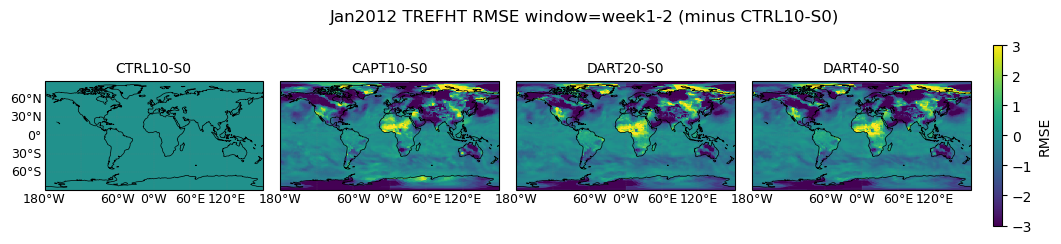

In [34]:
if __name__ == "__main__":
    data_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    diag_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_output/tcc_rmse_base"
    land_mask = "/compyfs/zhan391/acme_init/lnd_sea_mask/landmask_1x1.nc"

    # landmask settings
    landmask_var = "landfrac"
    land_threshold = 0.5

    # config knobs
    ens_start = 1
    ens_prefix = "EN"
    ens_width = 2
    ensmean_tag = "ENSMEAN"
    include_ensmean = True
    compute_ensmean_if_missing = False

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            period="201201-201203",
            season="Winter",
            init_date="2012-01-01",
            init_month=1,
            run="fc",
            freq="daily",
        ),
        "Jun2012": dict(
            models=["CTRL10-S1", "CAPT10-S1", "DART40-S1"],
            period="201206-201208",
            season="Summer",
            init_date="2012-06-01",
            init_month=6,
            run="fc",
            freq="daily",
        ),
    }
    
    # obs -> {model_var -> obs_var}
    all_var_dict = {
        "ERA5": {
            "UBOT": "U10",
            "VBOT": "V10",
            "PRECT": "PRECT",
            "PSL": "PSL",
            "U850": "U850",
            "V850": "V850",
            "T850": "T850",
            "Q850": "Q850",
            "Z500": "Z500",
            "OMEGA500": "OMEGA500",
            "OMEGA200": "OMEGA200",
            "OMEGA850": "OMEGA850",
            "U200": "U200",
            "V200": "V200",
            "U500": "U500",
            "V500": "V500",
            "FLDS": "FLDS",
            "FLDSC": "FLDSC",
            "FLNS": "FLNS",
            "FLNSC": "FLNSC",
            "FSDS": "FSDS",
            "FSDSC": "FSDSC",
            "FSNS": "FSNS",
            "FSNSC": "FSNSC",
            "LHFLX": "LHFLX",
            "SHFLX": "SHFLX",
            "QFLX": "QFLX",
            "TREFHT": "TREFHT",
            "TS": "TS",
            "PRECSL": "PRECSL",
            "PRECC": "PRECC",
            "PRECL": "PRECL",
        },
        "GPCP": {"PRECT": "PRECT"},
        "GPM": {"PRECT": "PRECT"},
        "NOAA-OLR": {"FLUT": "FLUT"},
    }

    lead_bins = {
        "week1-2": (1, 14),
        "week3-4": (15, 28),
        "week5-6": (29, 42),
        "week7-8": (43, 56),
    }

    # choice on plot
    group = "Jan2012"
    diag_var = "TREFHT"
    obs = "ERA5"
    region = "ALL"
    prefix = "s2s_base_tcc_rmse"
    metric = "RMSE"
    window = "week1-2"
    var_map = all_var_dict[obs]
    # obs_var = var_map.get(diag_var, diag_var)  # if you need it later
    
    # setup for figures
    ncols = 4
    vmin = -3
    vmax = 3 

    # FIX 1: no trailing comma
    figname = Path(f"{diag_path}/fig_{metric}_map_{diag_var}_{obs}_{window}.png")
    suptitle = "" # f"{group} {diag_var} {metric} {window} ({obs})",
    
    input_dir = Path(f"{diag_path}/{group}")
    if not input_dir.exists():
        raise FileNotFoundError(f"input_dir not found: {input_dir}")

    # experiment info
    freq = exp_list[group]["freq"]
    run = exp_list[group]["run"]
    models = exp_list[group]["models"]
    period = exp_list[group]["period"]

    exp_order = tuple(models)
    baseline_exp = models[0]
    
    # build exp metadata once
    exp_dict = build_experiments(data_path)
    nens_by_exp = {exp: int(exp_dict[exp]["nens"]) for exp in models}
    
    cfg = TccWindowMapPlotConfig(
        input_dir=input_dir,
        prefix=prefix,
        group=group,
        freq=freq,
        run=run,
        obs=obs,
        period=period,
        region=region,
        exp_order=exp_order,
        nens=nens_by_exp,  
        ens_start=ens_start,
        ens_prefix=ens_prefix,
        ens_width=ens_width,
        include_ensmean=include_ensmean,
        ensmean_tag=ensmean_tag,
        compute_ensmean_if_missing=compute_ensmean_if_missing,
        lead_bins=lead_bins,
        vmin=vmin,
        vmax=vmax,
        ncols=ncols,
    )
    
    plotter = TccWindowMapPlotter(cfg)

    plotter.plot_window_maps_all_exps(
        var=diag_var,
        exps=models,
        window=window,
        metric=metric,
        baseline_exp=baseline_exp,
        out_png=figname,
        show=True,
    )


In [ ]:
# ============================
# Config
# ============================

@dataclass(frozen=True)
class TccWindowMapPlotConfig:
    # where files live (e.g., diag_output/tcc_rmse_base/Jan2012)
    input_dir: Path

    # filename tokens
    prefix: str = "s2s_base_tcc_rmse"
    group: str = "Jan2012"
    freq: str = "daily"
    run: str = "fc"
    obs: str = "ERA5"
    period: str = "201201-201203"
    region: str = "ALL"

    # experiments
    exp_order: tuple[str, ...] = ()

    # ensemble settings (can be int or dict per-exp)
    nens: int | dict[str, int] = 40
    ens_start: int = 1
    ens_prefix: str = "EN"
    ens_width: int = 2
    include_ensmean: bool = True
    ensmean_tag: str = "ENSMEAN"
    compute_ensmean_if_missing: bool = False

    # window labels or (start,end) matching (optional; label selection recommended for your files)
    lead_bins: dict[str, tuple[int, int]] = field(default_factory=dict)

    # coordinate/dim candidates
    lat_candidates: tuple[str, ...] = ("lat", "latitude", "LAT")
    lon_candidates: tuple[str, ...] = ("lon", "longitude", "LON")
    window_dim_candidates: tuple[str, ...] = ("window", "lead_bin", "lead_window", "bin")
    lead_day_candidates: tuple[str, ...] = ("lead_days", "lead_day", "lead")

    # plot settings
    ncols: int = 4
    figsize_per_panel: tuple[float, float] = (3.6, 2.6)
    cmap: str = "RdBu_r"
    vmin: float | None = 0.0
    vmax: float | None = 1.0
    add_colorbar: bool = True
    verbose: bool = False


# ============================
# Plotter
# ============================

class TccWindowMapPlotter:
    """
    Window-TCC/RMSE 2D map plotter across experiments.

    Files:
      - member:  ..._{exp}_ENxx_{var}.nc   (vars: TCC, RMSE)
      - ensmean: ..._{exp}_ENSMEAN_{var}.nc (vars: TCC_ensmean, RMSE_ensmean)

    Pattern:
      {prefix}_{group}_{freq}_{run}_{obs}_{period}_{region}_{exp}_{tag}_{var}.nc
    """

    def __init__(self, cfg: TccWindowMapPlotConfig):
        if not cfg.lead_bins:
            object.__setattr__(
                cfg,
                "lead_bins",
                {
                    "week1-2": (1, 14),
                    "week3-4": (15, 28),
                    "week5-6": (29, 42),
                    "week7-8": (43, 56),
                },
            )
        self.cfg = cfg

    # ---------- tag helpers ----------
    def _ens_tag(self, k: int) -> str:
        return f"{self.cfg.ens_prefix}{k:0{self.cfg.ens_width}d}"

    def _get_nens_for_exp(self, exp: str) -> int:
        nens = self.cfg.nens
        if isinstance(nens, dict):
            if exp not in nens:
                raise KeyError(f"Missing nens for exp={exp}. Provided keys: {list(nens)}")
            return int(nens[exp])
        return int(nens)

    # ---------- file collection ----------
    def collect_member_and_ensmean_files(
        self, *, exp: str, var: str, strict: bool = False
    ) -> tuple[list[Path], list[int], Path | None]:
        nens = self._get_nens_for_exp(exp)

        member_files: list[Path] = []
        member_ens: list[int] = []

        for k in range(self.cfg.ens_start, self.cfg.ens_start + nens):
            tag = self._ens_tag(k)
            f = self.cfg.input_dir / (
                f"{self.cfg.prefix}_{self.cfg.group}_{self.cfg.freq}_{self.cfg.run}_"
                f"{self.cfg.obs}_{self.cfg.period}_{self.cfg.region}_{exp}_{tag}_{var}.nc"
            )
            if f.exists():
                member_files.append(f)
                member_ens.append(k)

        ensmean_file: Path | None = None
        if self.cfg.include_ensmean:
            tag = self.cfg.ensmean_tag
            f = self.cfg.input_dir / (
                f"{self.cfg.prefix}_{self.cfg.group}_{self.cfg.freq}_{self.cfg.run}_"
                f"{self.cfg.obs}_{self.cfg.period}_{self.cfg.region}_{exp}_{tag}_{var}.nc"
            )
            if f.exists():
                ensmean_file = f

        if strict and (not member_files) and (ensmean_file is None):
            raise FileNotFoundError(
                f"No files found for exp={exp} var={var} in {self.cfg.input_dir}\n"
                f"pattern: {self.cfg.prefix}_{self.cfg.group}_{self.cfg.freq}_{self.cfg.run}_"
                f"{self.cfg.obs}_{self.cfg.period}_{self.cfg.region}_{exp}_<TAG>_{var}.nc"
            )

        return member_files, member_ens, ensmean_file

    # ---------- dataset helpers ----------
    def _pick_metric_var(self, ds: xr.Dataset, metric: str) -> str:
        metric_u = metric.upper()

        if metric_u in ("ACC", "TCC", "CORR"):
            preferred = (
                "TCC_ensmean",
                "ACC_ensmean",
                "CORR_ensmean",
                "TCC",
                "ACC",
                "CORR",
                "corr",
                "acc",
                "tcc",
            )
            for n in preferred:
                if n in ds.data_vars:
                    return n
            for n in ds.data_vars:
                nu = n.upper()
                if nu.startswith(("TCC", "ACC", "CORR")):
                    return n
            raise KeyError(f"No TCC/ACC variable found. data_vars={list(ds.data_vars)}")

        if metric_u == "RMSE":
            preferred = ("RMSE_ensmean", "nRMSE_ensmean", "RMSE", "nRMSE", "rmse", "nrmse")
            for n in preferred:
                if n in ds.data_vars:
                    return n
            for n in ds.data_vars:
                nu = n.upper()
                if nu.startswith(("RMSE", "NRMSE")):
                    return n
            raise KeyError(f"No RMSE variable found. data_vars={list(ds.data_vars)}")

        raise ValueError(f"Unknown metric={metric}. Use 'ACC'/'TCC' or 'RMSE'.")

    def _select_window(self, da: xr.DataArray, window_sel) -> xr.DataArray:
        """
        Supports your file layout:
          dims: (region, window, lat, lon)
          coords: window (string), window_start(window), window_end(window)

        window_sel:
          - None: first window
          - int: window index
          - str: window label (recommended for your files)
          - (start,end): match window_start/window_end if present
        """
        for wdim in self.cfg.window_dim_candidates:
            if wdim in da.dims:
                if window_sel is None:
                    return da.isel({wdim: 0})
                if isinstance(window_sel, int):
                    return da.isel({wdim: window_sel})
                if isinstance(window_sel, str):
                    return da.sel({wdim: window_sel})

                if isinstance(window_sel, tuple) and len(window_sel) == 2:
                    start, end = window_sel
                    if ("window_start" in da.coords) and ("window_end" in da.coords):
                        ws = np.asarray(da["window_start"].values).astype(int)
                        we = np.asarray(da["window_end"].values).astype(int)
                        idx = np.where((ws == int(start)) & (we == int(end)))[0]
                        if idx.size == 0:
                            raise KeyError(
                                f"No window matched window_start={start}, window_end={end}. "
                                f"Available starts={ws}, ends={we}"
                            )
                        return da.isel({wdim: int(idx[0])})
                    return da.sel({wdim: window_sel})

                return da.sel({wdim: window_sel})

        # lead-day coord range (only if no window dim exists)
        if isinstance(window_sel, tuple) and len(window_sel) == 2:
            start, end = window_sel
            for ldn in self.cfg.lead_day_candidates:
                if ldn in da.coords:
                    sub = da.sel({ldn: slice(start, end)})
                    if ldn in sub.dims:
                        return sub.mean(ldn)
                    return sub

        return da
        
    def _format_lon_ticks(self, ax):
        ticks = np.arange(0, 361, 60)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{t}°E" if t <= 180 else f"{360-t}°W" for t in ticks])
    
    def _format_lat_ticks(self, ax):
        ticks = np.arange(-90, 91, 30)
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{abs(t)}°{'N' if t>0 else 'S' if t<0 else ''}" for t in ticks])

    def _open_metric_ensmean_2d(
        self, *, exp: str, var: str, metric: str, window_sel=None
    ) -> xr.DataArray:
        member_files, member_ens, ensmean_file = self.collect_member_and_ensmean_files(
            exp=exp, var=var, strict=True
        )

        if ensmean_file is None and not self.cfg.compute_ensmean_if_missing:
            raise FileNotFoundError(
                f"ENSMEAN file missing for exp={exp} var={var} and compute_ensmean_if_missing=False.\n"
                f"Found {len(member_files)} member files."
            )

        if ensmean_file is not None:
            ds = xr.open_dataset(ensmean_file)
            src = str(ensmean_file.name)
        else:
            dss = [xr.open_dataset(f) for f in member_files]
            ds = xr.concat(dss, dim="ens").mean("ens", skipna=True)
            src = f"computed-from-{len(member_files)}-members"

        vname = self._pick_metric_var(ds, metric)
        if self.cfg.verbose:
            print(f"[plot] exp={exp} var={var} metric={metric} -> {vname} ({src})")

        da = ds[vname]

        # region dimension exists (len=1) in your files
        if "region" in da.dims:
            da = da.isel(region=0)

        da = da.squeeze(drop=True)
        da = self._select_window(da, window_sel=window_sel).squeeze(drop=True)

        latn = next((n for n in self.cfg.lat_candidates if n in da.dims), None)
        lonn = next((n for n in self.cfg.lon_candidates if n in da.dims), None)
        if latn is None or lonn is None:
            raise ValueError(
                f"exp={exp} var={var}: output is NOT a 2D lat-lon map.\n"
                f"dims={da.dims}\n"
                f"This likely points to region-aggregated files (region={self.cfg.region}) rather than map files."
            )

        return da.transpose(latn, lonn)

    def _order_exps(self, exps: list[str]) -> list[str]:
        if self.cfg.exp_order:
            ordered = [e for e in self.cfg.exp_order if e in exps]
            rest = sorted([e for e in exps if e not in set(ordered)])
            return ordered + rest
        return sorted(exps)
        
    def _normalize_lon_if_needed(self, da: xr.DataArray) -> xr.DataArray:
        """
        Ensure longitude is in [-180, 180). If already so, do nothing.
        Safely handles 0–360 and mixed grids.
        """
        lon_name = next((n for n in self.cfg.lon_candidates if n in da.coords), None)
        if lon_name is None:
            raise KeyError("No longitude coordinate found in DataArray")
    
        lon = da[lon_name]
        lon_min = float(lon.min())
        lon_max = float(lon.max())
    
        # Already in -180..180 (with small tolerance)
        if lon_min >= -180.0 and lon_max <= 180.0:
            return da
    
        # Clearly 0..360-style
        if lon_min >= 0.0 and lon_max > 180.0:
            lon_new = ((lon + 180) % 360) - 180
            da = da.assign_coords({lon_name: lon_new})
            da = da.sortby(lon_name)
            return da
    
        # Mixed or weird grid → still normalize defensively
        lon_new = ((lon + 180) % 360) - 180
        da = da.assign_coords({lon_name: lon_new})
        da = da.sortby(lon_name)
        return da

    def plot_window_maps_all_exps(
        self,
        *,
        var: str,
        exps: list[str] | tuple[str, ...],
        window: str | tuple[int, int] | int | None = "week1-2",
        metric: str = "TCC",
        baseline_exp: str | None = None,
        out_png: Path | None = None,
        suptitle: str | None = None,
        show: bool = True,
    ):
        metric_u = metric.upper()
        if metric_u == "ACC":
            metric_u = "TCC"  # alias
    
        window_sel = window
        window_label = str(window)
    
        exps_ordered = self._order_exps(list(exps))
    
        # --- load maps (and normalize lon) ---
        maps: dict[str, xr.DataArray] = {}
        for exp in exps_ordered:
            da = self._open_metric_ensmean_2d(exp=exp, var=var, metric=metric_u, window_sel=window_sel)
            da = self._normalize_lon_if_needed(da)  # ensure lon in [-180, 180)
            maps[exp] = da
    
        # --- baseline differencing rules ---
        is_rmse = metric_u in ("RMSE", "NRMSE")
        if is_rmse and baseline_exp is not None:
            if baseline_exp not in maps:
                raise KeyError(f"baseline_exp={baseline_exp} not in exps: {exps_ordered}")
            base = maps[baseline_exp]
            for exp in exps_ordered:
                maps[exp] = maps[exp] - base
    
        # --- choose plot defaults based on metric ---
        # (Use cfg values if user provided them; otherwise set sensible defaults.)
        cmap = self.cfg.cmap
        vmin = self.cfg.vmin
        vmax = self.cfg.vmax
    
        if is_rmse:
            # RMSE absolute: sequential; RMSE difference: diverging centered at 0
            if baseline_exp is None:
                if (vmin is None) or (vmax is None):
                    # robust limits across all panels
                    allv = np.concatenate([np.ravel(maps[e].values) for e in exps_ordered])
                    allv = allv[np.isfinite(allv)]
                    if allv.size:
                        vmin = float(np.nanpercentile(allv, 2))
                        vmax = float(np.nanpercentile(allv, 98))
                if cmap == "RdBu_r":  # your previous default
                    cmap = "viridis"
            else:
                # difference: symmetric around 0
                if (vmin is None) or (vmax is None):
                    allv = np.concatenate([np.ravel(maps[e].values) for e in exps_ordered])
                    allv = allv[np.isfinite(allv)]
                    m = float(np.nanpercentile(np.abs(allv), 98)) if allv.size else 1.0
                    vmin, vmax = -m, m
                if cmap == "viridis":
                    cmap = "RdBu_r"
        else:
            # TCC: diverging in [-1,1] by default, unless user overrides
            if (vmin is None) or (vmax is None):
                vmin, vmax = -1.0, 1.0
                
        # --- layout ---
        n = len(exps_ordered)
        ncols = max(1, int(self.cfg.ncols))
        nrows = int(np.ceil(n / ncols))
        fw = self.cfg.figsize_per_panel[0] * ncols
        fh = self.cfg.figsize_per_panel[1] * nrows
    
        if HAS_CARTOPY:
            proj = ccrs.PlateCarree()
            fig, axes = plt.subplots(
                nrows, ncols,
                figsize=(fw, fh),
                constrained_layout=False,
                subplot_kw=dict(projection=proj),
            )
            lon_formatter = LongitudeFormatter(zero_direction_label=True, dateline_direction_label=True)
            lat_formatter = LatitudeFormatter()
        else:
            fig, axes = plt.subplots(nrows, ncols, figsize=(fw, fh), constrained_layout=False)
    
        fig.subplots_adjust(wspace=0.08, hspace=0.18)
        axes = np.array(axes).reshape(nrows, ncols)
    
        # consistent global settings
        extent = (-180, 180, -90, 90)
        lon_ticks = np.arange(-180, 181, 60)
        lat_ticks = np.arange(-90, 91, 30)
    
        im = None
        for i, exp in enumerate(exps_ordered):
            r, c = divmod(i, ncols)
            ax = axes[r, c]
    
            da = maps[exp]
            lat = da[da.dims[0]].values
            lon = da[da.dims[1]].values
            Z = da.values
    
            if HAS_CARTOPY:
                ax.set_extent(extent, crs=ccrs.PlateCarree())
    
                im = ax.pcolormesh(
                    lon, lat, Z,
                    transform=ccrs.PlateCarree(),
                    vmin=vmin, vmax=vmax,
                    cmap=cmap,
                )
                ax.coastlines(resolution="110m", linewidth=0.5)
    
                gl = ax.gridlines(
                    crs=ccrs.PlateCarree(),
                    draw_labels=True,
                    linewidth=0.3,
                    color="gray",
                    alpha=0.35,
                    linestyle="--",
                    x_inline=False,
                    y_inline=False,
                )
                gl.xlocator = FixedLocator(lon_ticks)
                gl.ylocator = FixedLocator(lat_ticks)
                gl.xformatter = lon_formatter
                gl.yformatter = lat_formatter
    
                gl.top_labels = False
                gl.right_labels = False
                gl.bottom_labels = (r == nrows - 1)
                gl.left_labels = (c == 0)
    
                gl.xpadding = 2
                gl.ypadding = 2
                gl.xlabel_style = {"size": 9}
                gl.ylabel_style = {"size": 9}
    
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                im = ax.pcolormesh(lon, lat, Z, vmin=vmin, vmax=vmax, cmap=cmap)
                ax.set_xlim(extent[0], extent[1])
                ax.set_ylim(extent[2], extent[3])
                ax.set_xticks(lon_ticks)
                ax.set_yticks(lat_ticks)
                if r != nrows - 1:
                    ax.tick_params(axis="x", labelbottom=False)
                if c != 0:
                    ax.tick_params(axis="y", labelleft=False)
    
            ax.set_title(exp, fontsize=10)
    
        for j in range(n, nrows * ncols):
            rr, cc = divmod(j, ncols)
            axes[rr, cc].axis("off")
    
        if suptitle is None:
            base_txt = f"{self.cfg.group} {var} {metric_u} window={window_label}"
            if baseline_exp is not None:
                base_txt += f" (Δ vs {baseline_exp})"
            suptitle = base_txt
        fig.suptitle(suptitle, fontsize=12)
    
        if self.cfg.add_colorbar and im is not None:
            fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
    
        if out_png is not None:
            out_png = Path(out_png)
            out_png.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out_png, dpi=200, bbox_inches="tight")
    
        if show:
            plt.show()
        else:
            plt.close(fig)
    
        return fig
